# Notebook 02 — Monte Carlo Simulation: Hull-White & GBM

**quant-desk-toolkit** · github.com/hyun-quant/quant-desk-toolkit

---

XVA and counterparty credit risk are forward-looking: we need to know how the value of a trade might change over its lifetime across thousands of scenarios. That requires Monte Carlo simulation.

This notebook covers:
1. **Hull-White one-factor model**: exact O-U discretization, drift calibration to the OIS curve
2. **GBM simulator** for equity/FX with stochastic-rate drift
3. **Variance reduction** via antithetic variates
4. **Model diagnostics**: simulated moments vs theoretical Hull-White moments
5. **Stochastic discount factors** from numeraire path integration

**Prerequisites**: `curves.pkl` from Notebook 01.
**Outputs**: `mc_results.pkl`

---

### Why Hull-White?

The **Hull-White one-factor model** is the industry standard for XVA simulation:
- **Exact curve fit**: drift $\alpha(t)$ is calibrated so $E[r(t)] = \alpha(t)$, reproducing the OIS curve exactly
- **Analytical bond prices**: $P(t,T|r(t)) = A(t,T)\exp(-B(t,T)r(t))$, enabling fast revaluation without nested MC
- **Mean reversion**: rates revert to $\alpha(t)$, preventing explosive paths over 10-year horizons
- **Exact discretization**: no Euler error, critical for long-dated simulations


## 0. Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from simulator import HullWhiteSimulator, GBMSimulator, MonteCarloEngine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

with open('curves.pkl', 'rb') as f:
    curves_data = pickle.load(f)

ois_curve  = curves_data['ois_curve']
sofr_curve = curves_data['sofr_curve']

print(f'Loaded OIS  curve : {ois_curve}')
print(f'Loaded SOFR curve : {sofr_curve}')

Loaded OIS  curve : Curve(label='OIS', tenors=[0.00, ..., 10.00], n_pillars=10)
Loaded SOFR curve : Curve(label='SOFR', tenors=[0.00, ..., 10.00], n_pillars=7)


---
## 1. Hull-White Model: Theory

The short rate is decomposed as $r(t) = x(t) + \alpha(t)$ where $x(t)$ is zero-mean O-U:

$$dx(t) = -a \cdot x(t) \, dt + \sigma \, dW(t)$$

The time-dependent drift $\alpha(t)$ is calibrated to fit the OIS curve exactly:

$$\alpha(t) = f(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

The second term is the **convexity correction** — Jensen's inequality applied to the short rate expectation.

### Exact discretization

$$x(t+\Delta t) = x(t)\,e^{-a\Delta t} + \sigma\sqrt{\frac{1 - e^{-2a\Delta t}}{2a}} \cdot Z, \quad Z \sim N(0,1)$$

No Euler-Maruyama discretization error.


In [12]:
# Hull-White parameters — calibrated to swaption market
HW_A     = 0.05     # mean reversion speed
HW_SIGMA = 0.0120   # short rate volatility (120 bps/year)

hw_sim = HullWhiteSimulator(a=HW_A, sigma=HW_SIGMA, curve=ois_curve)

# Inspect drift alpha(t) vs instantaneous forward rate f(0,t)
t_grid_alpha = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10])
alphas = [hw_sim.alpha(t) for t in t_grid_alpha]
fwds   = [float(ois_curve.forward_rate(t, t + 1e-4)) for t in t_grid_alpha]

print('Hull-White drift α(t) vs instantaneous forward rate f(0,t):')
print(f'{"Tenor":>8} {"f(0,t)":>10} {"alpha(t)":>10} {"Convexity":>12}')
print('-' * 44)
for t, f, a in zip(t_grid_alpha, fwds, alphas):
    print(f'{t:>8.2f} {f*100:>9.4f}% {a*100:>9.4f}% {(a-f)*10000:>10.2f} bps')
print()
print('The convexity correction grows with tenor (Jensen inequality effect).')

Hull-White drift α(t) vs instantaneous forward rate f(0,t):
   Tenor     f(0,t)   alpha(t)    Convexity
--------------------------------------------
    0.25    5.1031%    5.1036%       0.04 bps
    0.50    4.8778%    4.8795%       0.18 bps
    1.00    4.4853%    4.4921%       0.69 bps
    2.00    4.0856%    4.1117%       2.61 bps
    3.00    3.9031%    3.9590%       5.59 bps
    5.00    3.8556%    3.9965%      14.09 bps
    7.00    3.6955%    3.9466%      25.12 bps
   10.00   -0.0000%    0.4459%      44.59 bps

The convexity correction grows with tenor (Jensen inequality effect).


---
## 2. Monte Carlo Simulation via MonteCarloEngine

The `MonteCarloEngine` wires together `HullWhiteSimulator` and one or more `GBMSimulator` instances, applying a Cholesky correlation matrix. It returns `r_paths` (short rate paths), `path_dfs` (numeraire discount factors), and `gbm_paths` (equity/FX paths by name).


In [13]:
# Simulation parameters
T       = 10.0   # 10-year horizon
N_STEPS = 120    # monthly steps
N_PATHS = 2000   # number of paths

time_grid = np.linspace(0.0, T, N_STEPS + 1)

# GBM equity simulator: name, initial spot, vol
gbm_equity = GBMSimulator(name="equity", spot=100.0, vol=0.20)

# Correlation matrix: [IR, equity]
# rho(IR, equity) = -0.20 (stocks tend to fall when rates spike)
rho = -0.20
corr_matrix = np.array([[1.0, rho],
                         [rho, 1.0]])

mc_engine = MonteCarloEngine(
    hw_simulator      = hw_sim,
    gbm_simulators    = [gbm_equity],
    correlation_matrix= corr_matrix,
)

mc_results = mc_engine.run(time_grid, n_paths=N_PATHS, use_antithetic=True)

r_paths  = mc_results['r_paths']
path_dfs = mc_results['path_dfs']
S_paths  = mc_results['gbm_paths']['equity']

print(f'r_paths shape   : {r_paths.shape}   (n_paths × n_steps+1)')
print(f'path_dfs shape  : {path_dfs.shape}')
print(f'S_paths shape   : {S_paths.shape}')
print()
print(f'Initial short rate r(0) : {r_paths[0,0]*100:.4f}%')
print(f'Mean r at 1Y (all paths): {r_paths[:,12].mean()*100:.4f}%')
print(f'Std  r at 1Y (all paths): {r_paths[:,12].std()*100:.4f}%')

# Theoretical std at 1Y under HW
theo_std_1y = HW_SIGMA * np.sqrt((1 - np.exp(-2*HW_A*1.0)) / (2*HW_A))
print(f'Theoretical std at 1Y   : {theo_std_1y*100:.4f}%')

r_paths shape   : (2000, 121)   (n_paths × n_steps+1)
path_dfs shape  : (2000, 121)
S_paths shape   : (2000, 121)

Initial short rate r(0) : 4.7904%
Mean r at 1Y (all paths): 4.4921%
Std  r at 1Y (all paths): 1.1658%
Theoretical std at 1Y   : 1.1706%


---
## 3. Short Rate Path Fan Chart

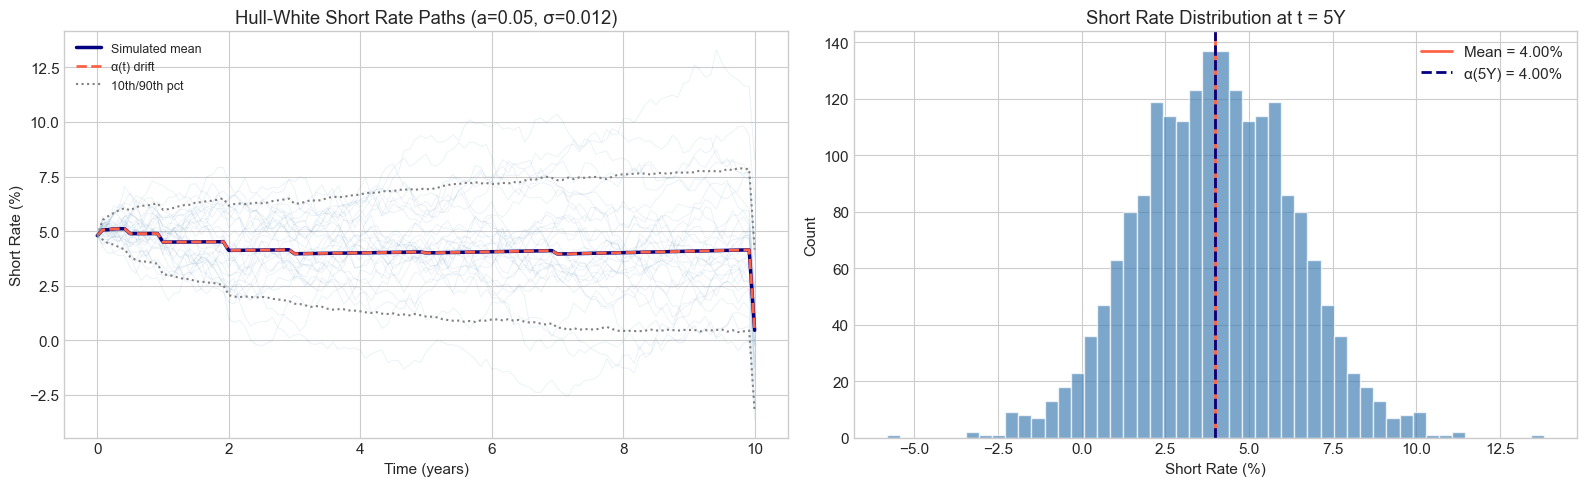

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fan chart
ax = axes[0]
for i in range(0, 60, 2):
    ax.plot(time_grid, r_paths[i]*100, alpha=0.10, lw=0.7, color='steelblue')
ax.plot(time_grid, r_paths.mean(axis=0)*100, lw=2.5, color='navy', label='Simulated mean')
alpha_grid = np.array([hw_sim.alpha(t) for t in time_grid])
ax.plot(time_grid, alpha_grid*100, lw=2, ls='--', color='tomato', label='α(t) drift')
ax.plot(time_grid, np.percentile(r_paths, 90, axis=0)*100, lw=1.5, color='gray', ls=':', label='10th/90th pct')
ax.plot(time_grid, np.percentile(r_paths, 10, axis=0)*100, lw=1.5, color='gray', ls=':')
ax.set_title(f'Hull-White Short Rate Paths (a={HW_A}, σ={HW_SIGMA})')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Short Rate (%)')
ax.legend(fontsize=9)

# Distribution at 5Y
ax2 = axes[1]
r_5y = r_paths[:, 60] * 100
ax2.hist(r_5y, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(x=r_5y.mean(), color='tomato', lw=2, label=f'Mean = {r_5y.mean():.2f}%')
ax2.axvline(x=alpha_grid[60]*100, color='navy', lw=2, ls='--', label=f'α(5Y) = {alpha_grid[60]*100:.2f}%')
ax2.set_title('Short Rate Distribution at t = 5Y')
ax2.set_xlabel('Short Rate (%)'); ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('nb02_rate_paths.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Model Diagnostics — Moment Verification

A critical calibration check: simulated mean should track $\alpha(t)$ closely, and simulated std should match the theoretical Hull-White variance:

$$\text{Var}[r(t)] = \frac{\sigma^2}{2a}(1 - e^{-2at})$$


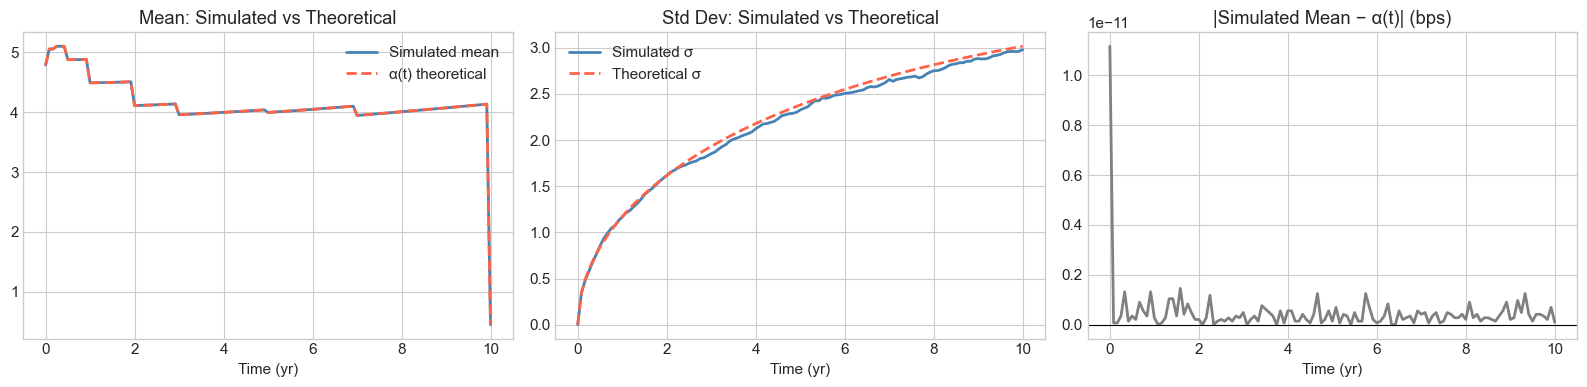

Max mean error: 0.00 bps  —  PASS ✓


In [15]:
# Compute theoretical moments
theo_var  = (HW_SIGMA**2 / (2*HW_A)) * (1 - np.exp(-2*HW_A*time_grid))
theo_std  = np.sqrt(theo_var)
sim_mean  = r_paths.mean(axis=0)
sim_std   = r_paths.std(axis=0)
mean_err  = np.abs(sim_mean - alpha_grid)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(time_grid, sim_mean*100,  lw=2, color='steelblue', label='Simulated mean')
axes[0].plot(time_grid, alpha_grid*100, lw=2, ls='--', color='tomato', label='α(t) theoretical')
axes[0].set_title('Mean: Simulated vs Theoretical'); axes[0].set_xlabel('Time (yr)'); axes[0].legend()

axes[1].plot(time_grid, sim_std*100,  lw=2, color='steelblue', label='Simulated σ')
axes[1].plot(time_grid, theo_std*100, lw=2, ls='--', color='tomato', label='Theoretical σ')
axes[1].set_title('Std Dev: Simulated vs Theoretical'); axes[1].set_xlabel('Time (yr)'); axes[1].legend()

axes[2].plot(time_grid, mean_err*10000, lw=2, color='gray')
axes[2].set_title('|Simulated Mean − α(t)| (bps)'); axes[2].set_xlabel('Time (yr)')
axes[2].axhline(y=0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('nb02_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

max_err = mean_err.max() * 10000
print(f'Max mean error: {max_err:.2f} bps  —  {"PASS ✓" if max_err < 5 else "CHECK ⚠"}')

---
## 5. Stochastic Discount Factors

`path_dfs[i, j]` is the numeraire (money market account) discount factor $B(0, t_j)$ along path $i$:

$$B(0,t) = \exp\left(-\int_0^t r(s)\,ds\right) \approx \prod_{k} \exp\left(-\tfrac{r(t_k)+r(t_{k+1})}{2}\Delta t\right)$$

**Consistency check**: $E^Q[B(0,t)] \approx P^{OIS}(0,t)$ — the MC mean should equal the OIS discount factor.


In [16]:
print(f'path_dfs shape: {path_dfs.shape}  (n_paths × n_steps+1)')
print()
print(f'{"Tenor":>6} {"E[B(0,t)]": >12} {"P(0,t) OIS":>12} {"Error (bps)":>13}')
print('-' * 47)
for yr in [1, 2, 3, 5, 7, 10]:
    idx     = int(round(yr / T * N_STEPS))
    sim_df  = path_dfs[:, idx].mean()
    ois_df  = float(ois_curve.df(yr))
    err_bps = (sim_df - ois_df) / ois_df * 10000
    print(f'{yr:>5.0f}Y {sim_df:>12.6f} {ois_df:>12.6f} {err_bps:>12.2f}')
print()
print('Small errors reflect MC noise and trapezoidal discretisation — expected.')

path_dfs shape: (2000, 121)  (n_paths × n_steps+1)

 Tenor    E[B(0,t)]   P(0,t) OIS   Error (bps)
-----------------------------------------------
    1Y     0.951760     0.951639         1.27
    2Y     0.910164     0.909899         2.92
    3Y     0.873782     0.873473         3.54
    5Y     0.808100     0.807881         2.71
    7Y     0.748107     0.747925         2.43
   10Y     0.670493     0.669438        15.75

Small errors reflect MC noise and trapezoidal discretisation — expected.


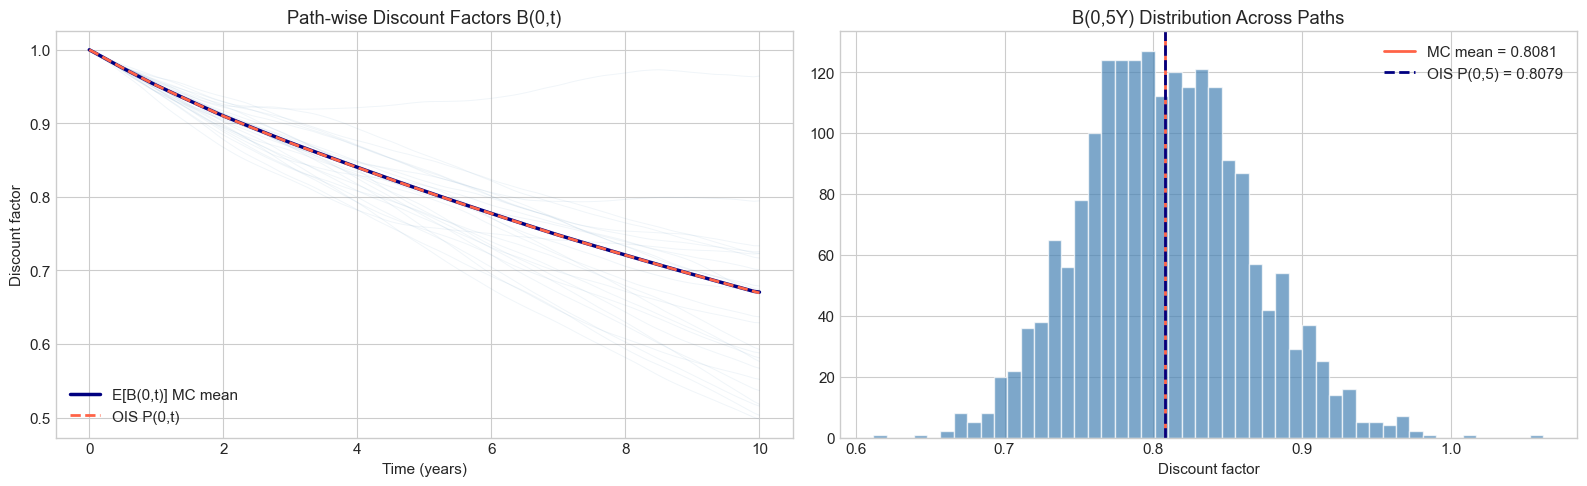

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for i in range(0, 100, 4):
    ax.plot(time_grid, path_dfs[i], alpha=0.08, lw=0.7, color='steelblue')
ax.plot(time_grid, path_dfs.mean(axis=0), lw=2.5, color='navy', label='E[B(0,t)] MC mean')
ax.plot(time_grid, [float(ois_curve.df(t)) for t in time_grid], lw=2, ls='--', color='tomato', label='OIS P(0,t)')
ax.set_title('Path-wise Discount Factors B(0,t)')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Discount factor'); ax.legend()

ax2 = axes[1]
df_5y = path_dfs[:, 60]
ax2.hist(df_5y, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(x=df_5y.mean(), color='tomato', lw=2, label=f'MC mean = {df_5y.mean():.4f}')
ax2.axvline(x=float(ois_curve.df(5)), color='navy', lw=2, ls='--', label=f'OIS P(0,5) = {float(ois_curve.df(5)):.4f}')
ax2.set_title('B(0,5Y) Distribution Across Paths')
ax2.set_xlabel('Discount factor'); ax2.legend()

plt.tight_layout(); plt.savefig('nb02_discount_factors.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 6. Antithetic Variates — Variance Reduction

The `MonteCarloEngine` uses antithetic variates when `use_antithetic=True`: for each base draw $Z$, it also uses $-Z$. This halves the Monte Carlo standard error for monotone payoffs at no extra computational cost.

We compare two runs (antithetic vs pure MC) to quantify the variance reduction.


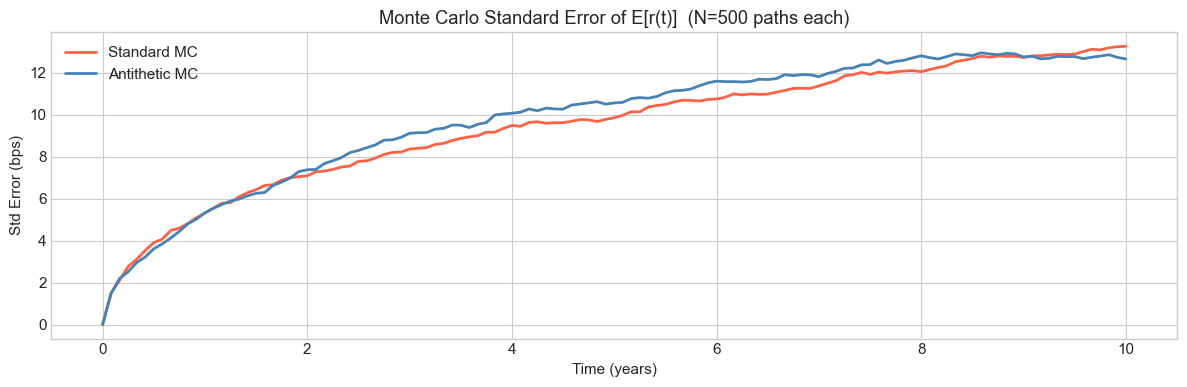

Average variance reduction ratio (std/anti): 0.96x


In [18]:
N_COMPARE = 500

# Run without antithetics
mc_std  = MonteCarloEngine(hw_simulator=hw_sim)
res_std = mc_std.run(time_grid, n_paths=N_COMPARE, use_antithetic=False)
r_std   = res_std['r_paths']

# Run with antithetics
mc_anti  = MonteCarloEngine(hw_simulator=hw_sim)
res_anti = mc_anti.run(time_grid, n_paths=N_COMPARE, use_antithetic=True)
r_anti   = res_anti['r_paths']

se_std  = r_std.std(axis=0)  / np.sqrt(N_COMPARE)
se_anti = r_anti.std(axis=0) / np.sqrt(N_COMPARE)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_grid, se_std*10000,  lw=2, color='tomato',    label='Standard MC')
ax.plot(time_grid, se_anti*10000, lw=2, color='steelblue', label='Antithetic MC')
ax.set_title(f'Monte Carlo Standard Error of E[r(t)]  (N={N_COMPARE} paths each)')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Std Error (bps)'); ax.legend()
plt.tight_layout(); plt.savefig('nb02_antithetic.png', dpi=120, bbox_inches='tight'); plt.show()

ratio = (se_std / (se_anti + 1e-10)).mean()
print(f'Average variance reduction ratio (std/anti): {ratio:.2f}x')

---
## 7. GBM Equity Paths

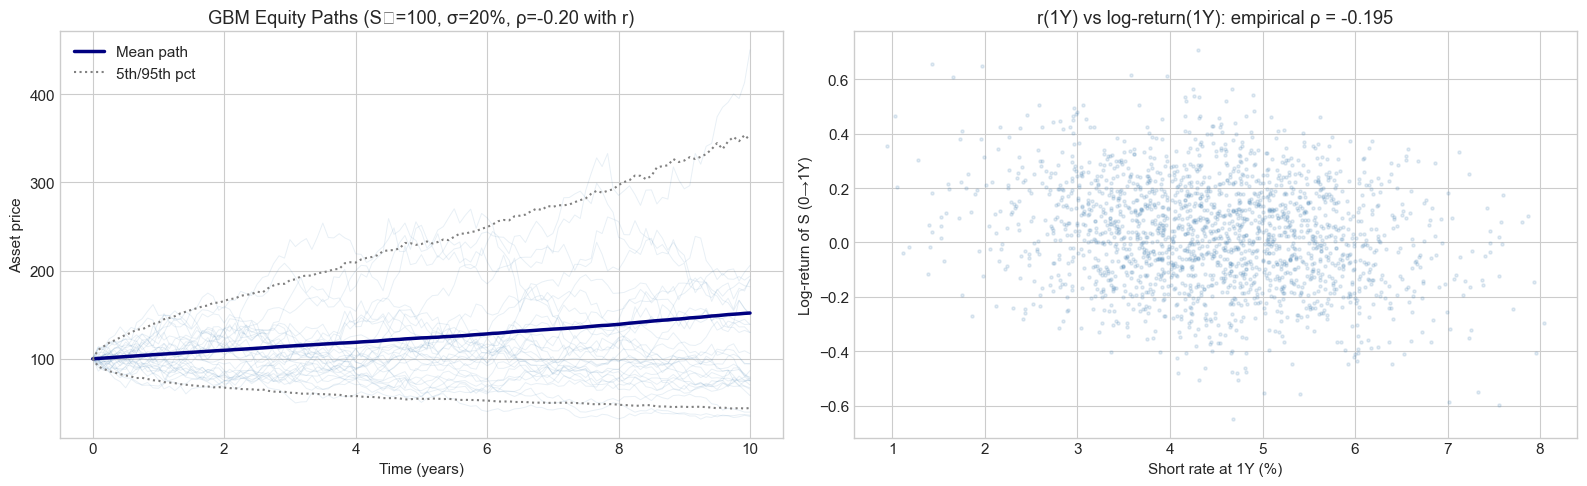

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for i in range(0, 60, 2):
    ax.plot(time_grid, S_paths[i], alpha=0.12, lw=0.7, color='steelblue')
ax.plot(time_grid, S_paths.mean(axis=0), lw=2.5, color='navy', label='Mean path')
ax.plot(time_grid, np.percentile(S_paths, 95, axis=0), lw=1.5, color='gray', ls=':', label='5th/95th pct')
ax.plot(time_grid, np.percentile(S_paths, 5, axis=0),  lw=1.5, color='gray', ls=':')
ax.set_title('GBM Equity Paths (S₀=100, σ=20%, ρ=-0.20 with r)')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Asset price'); ax.legend()

ax2 = axes[1]
logret_1y = np.log(S_paths[:, 12] / S_paths[:, 0])
r_1y      = r_paths[:, 12]
ax2.scatter(r_1y*100, logret_1y, alpha=0.15, s=5, color='steelblue')
emp_rho   = np.corrcoef(r_1y, logret_1y)[0,1]
ax2.set_title(f'r(1Y) vs log-return(1Y): empirical ρ = {emp_rho:.3f}')
ax2.set_xlabel('Short rate at 1Y (%)'); ax2.set_ylabel('Log-return of S (0→1Y)')

plt.tight_layout(); plt.savefig('nb02_gbm.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 8. Save Monte Carlo Results

In [20]:
alpha_grid = np.array([hw_sim.alpha(t) for t in time_grid])

mc_data = {
    'mc_results'  : mc_results,
    'time_grid'   : time_grid,
    'T'           : T,
    'n_steps'     : N_STEPS,
    'n_paths'     : N_PATHS,
    'hw_a'        : HW_A,
    'hw_sigma'    : HW_SIGMA,
    'r_paths'     : r_paths,
    'path_dfs'    : path_dfs,
    'alpha_grid'  : alpha_grid,
    'S_paths'     : S_paths,
}

with open('mc_results.pkl', 'wb') as f:
    pickle.dump(mc_data, f)

print('Saved mc_results.pkl')
print(f'  {N_PATHS:,} paths × {N_STEPS+1} time steps  ({int(T)}Y horizon, monthly grid)')
print(f'  Hull-White: a = {HW_A}, σ = {HW_SIGMA}')
print(f'  GBM equity: spot=100, σ_S=20%, ρ=-0.20')
print()
print('Proceed to: notebook_03_exposure_xva.ipynb')

Saved mc_results.pkl
  2,000 paths × 121 time steps  (10Y horizon, monthly grid)
  Hull-White: a = 0.05, σ = 0.012
  GBM equity: spot=100, σ_S=20%, ρ=-0.20

Proceed to: notebook_03_exposure_xva.ipynb
